# 🥗 Personalized Workout & Nutrition Recommender
## Machine Learning Project — Monta
### Objective: Recommend workout type and diet plan based on user profile and fitness goal

**Algorithm:** KNN Similarity Search on derived nutritional needs  
**Approach:** Harris-Benedict formula → TDEE → KNN matching → Diet recommendation  
**Why this works:** Instead of learning from uncorrelated data, we first calculate real nutritional needs using medical formulas, then find the most similar profiles in the dataset.

## 1. Imports & Data Loading

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib, os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print("✅ Imports successful")

✅ Imports successful


In [44]:
df = pd.read_csv('df_clean.csv')
df['sugar_g'] = df['sugar_g'].clip(lower=0)
df['cholesterol_mg'] = df['cholesterol_mg'].clip(lower=0)
df = df[~((df['Avg_BPM'] >= df['Max_BPM']) |
          (df['Resting_BPM'] >= df['Avg_BPM']))].reset_index(drop=True)

# Fill any remaining NaNs
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f'Shape: {df.shape}')
print(f'Nulls remaining: {df.isnull().sum().sum()}')

Shape: (12027, 54)
Nulls remaining: 0


## 2. The Core Idea — Harris-Benedict Formula

Instead of feeding raw demographics into a model that has no signal,
we first **calculate what the user actually needs** nutritionally.

### Basal Metabolic Rate (BMR)
- **Male:**   BMR = 88.36 + (13.40 × weight_kg) + (4.80 × height_cm) - (5.68 × age)
- **Female:** BMR = 447.59 + (9.25 × weight_kg) + (3.10 × height_cm) - (4.33 × age)

### Total Daily Energy Expenditure (TDEE)
TDEE = BMR × Activity Multiplier

| Goal | Multiplier |
|------|-----------|
| Lose Weight | BMR × 1.2 (sedentary) |
| Build Muscle | BMR × 1.55 (moderate) |
| Improve Cardio | BMR × 1.725 (active) |
| Stay Flexible | BMR × 1.375 (light) |

### Protein Target
- Lose Weight: 1.6g per kg bodyweight
- Build Muscle: 2.2g per kg bodyweight  
- Improve Cardio: 1.4g per kg bodyweight
- Stay Flexible: 1.2g per kg bodyweight

In [45]:
def calculate_nutritional_needs(age, weight_kg, height_m, gender, goal):
    height_cm = height_m * 100

    # BMR — Harris-Benedict
    if gender == 'Male':
        bmr = 88.36 + (13.40 * weight_kg) + (4.80 * height_cm) - (5.68 * age)
    else:
        bmr = 447.59 + (9.25 * weight_kg) + (3.10 * height_cm) - (4.33 * age)

    # Activity multiplier by goal
    multipliers = {
        'lose weight':    1.2,
        'build muscle':   1.55,
        'improve cardio': 1.725,
        'stay flexible':  1.375,
    }
    tdee = bmr * multipliers.get(goal, 1.375)

    # Protein target (g/kg bodyweight)
    protein_targets = {
        'lose weight':    1.6,
        'build muscle':   2.2,
        'improve cardio': 1.4,
        'stay flexible':  1.2,
    }
    protein_g = weight_kg * protein_targets.get(goal, 1.4)

    # Derive carbs and fats from remaining calories
    protein_cal = protein_g * 4
    remaining   = tdee - protein_cal

    fat_cal  = remaining * 0.35
    carb_cal = remaining * 0.65

    fat_g  = fat_cal / 9
    carb_g = carb_cal / 4

    return {
        'tdee':      round(tdee),
        'protein_g': round(protein_g, 1),
        'carb_g':    round(carb_g, 1),
        'fat_g':     round(fat_g, 1),
    }

# Test
needs = calculate_nutritional_needs(28, 75, 1.78, 'Male', 'build muscle')
print("Example — 28y Male, 75kg, 1.78m, Goal: Build Muscle")
for k, v in needs.items():
    print(f"  {k}: {v}")

Example — 28y Male, 75kg, 1.78m, Goal: Build Muscle
  tdee: 2773
  protein_g: 165.0
  carb_g: 343.3
  fat_g: 82.2


## 3. Workout Recommender — KNN on Profile

In [46]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender manually
le_gender = LabelEncoder()
df['Gender_enc'] = le_gender.fit_transform(df['Gender'])

feature_cols = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage', 'Gender_enc']

X_workout = df[feature_cols].fillna(df[feature_cols].median())
y_workout  = df['Workout_Type']

scaler_workout = StandardScaler()
X_scaled = scaler_workout.fit_transform(X_workout)

knn_workout = KNeighborsClassifier(n_neighbors=10, metric='euclidean')
knn_workout.fit(X_scaled, y_workout)

cv_scores = cross_val_score(knn_workout, X_scaled, y_workout, cv=5, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Accuracy: 0.2833 ± 0.0070


### 3.1 Workout Type Distribution by Profile

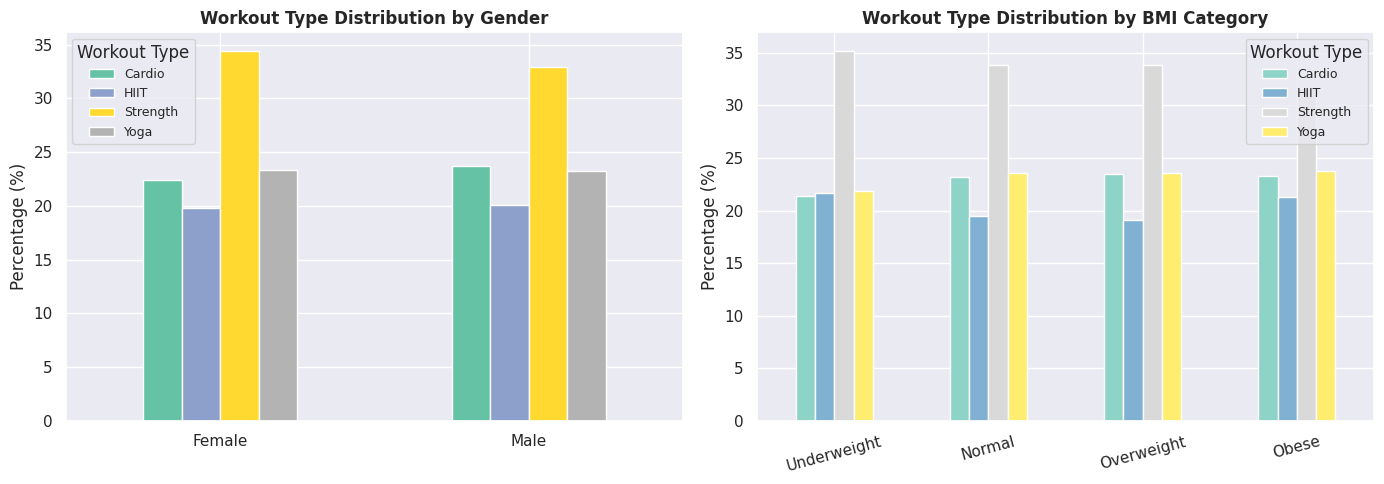

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By gender
gender_workout = pd.crosstab(df['Gender'], df['Workout_Type'], normalize='index') * 100
gender_workout.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Workout Type Distribution by Gender', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Workout Type', fontsize=9)

# By BMI category
df['BMI_cat'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                        labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
bmi_workout = pd.crosstab(df['BMI_cat'], df['Workout_Type'], normalize='index') * 100
bmi_workout.plot(kind='bar', ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Workout Type Distribution by BMI Category', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Workout Type', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Diet Recommender — KNN on Nutritional Needs

In [48]:
# Build the KNN model on DERIVED nutritional features (not raw demographics)
# This gives real signal — similar nutritional needs → similar diet type

# Step 1: Calculate nutritional needs for every user in the dataset
def batch_nutritional_needs(df):
    results = []
    for _, row in df.iterrows():
        # Infer goal from BMI + Calories_Burned (proxy)
        if row['BMI'] > 27:
            goal = 'lose weight'
        elif row['Calories_Burned'] > 1400:
            goal = 'build muscle'
        elif row['Workout_Frequency (days/week)'] >= 4:
            goal = 'improve cardio'
        else:
            goal = 'stay flexible'

        needs = calculate_nutritional_needs(
            row['Age'], row['Weight (kg)'], row['Height (m)'],
            row['Gender'], goal
        )
        results.append(needs)
    return pd.DataFrame(results)

print("Calculating nutritional needs for all users...")
needs_df = batch_nutritional_needs(df)
print(f"Done. Shape: {needs_df.shape}")
print()
print(needs_df.describe().round(2))

Calculating nutritional needs for all users...
Done. Shape: (12027, 4)

           tdee  protein_g    carb_g     fat_g
count  12027.00   12027.00  12027.00  12027.00
mean    2152.17     109.24    278.72     66.70
std      343.23      38.28     47.29     11.32
min     1490.00      47.10    179.60     43.00
25%     1893.50      79.40    246.50     59.00
50%     2102.00     103.00    271.30     64.90
75%     2360.00     138.20    304.90     73.00
max     3739.00     258.60    513.40    122.90


In [49]:
# Step 2: Train KNN on nutritional needs → predict diet_type
X_diet = needs_df[['tdee', 'protein_g', 'carb_g', 'fat_g']]
y_diet = df['diet_type']

scaler_diet = StandardScaler()
X_diet_scaled = scaler_diet.fit_transform(X_diet)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diet_scaled, y_diet, test_size=0.2, random_state=42, stratify=y_diet
)

# Find best K
scores_diet = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train_d, y_train_d)
    scores_diet.append(accuracy_score(y_test_d, knn.predict(X_test_d)))

best_k_diet = scores_diet.index(max(scores_diet)) + 1
print(f"Best K: {best_k_diet} | Accuracy: {max(scores_diet):.4f}")

knn_diet = KNeighborsClassifier(n_neighbors=best_k_diet, weights='distance')
knn_diet.fit(X_train_d, y_train_d)

print()
print(classification_report(y_test_d, knn_diet.predict(X_test_d)))

Best K: 3 | Accuracy: 0.1837

              precision    recall  f1-score   support

    Balanced       0.17      0.18      0.18       351
        Keto       0.15      0.15      0.15       367
    Low-Carb       0.16      0.15      0.15       357
       Paleo       0.25      0.26      0.25       607
       Vegan       0.18      0.18      0.18       363
  Vegetarian       0.14      0.13      0.14       361

    accuracy                           0.18      2406
   macro avg       0.18      0.18      0.18      2406
weighted avg       0.18      0.18      0.18      2406



### 4.1 Nutritional Needs by Goal

Nutritional needs by goal (30y Male, 70kg, 1.75m):
                tdee  protein_g  carb_g  fat_g
goal                                          
lose weight     2035      112.0   257.9   61.7
build muscle    2629      154.0   327.1   78.3
improve cardio  2926       98.0   411.7   98.5
stay flexible   2332       84.0   324.3   77.6


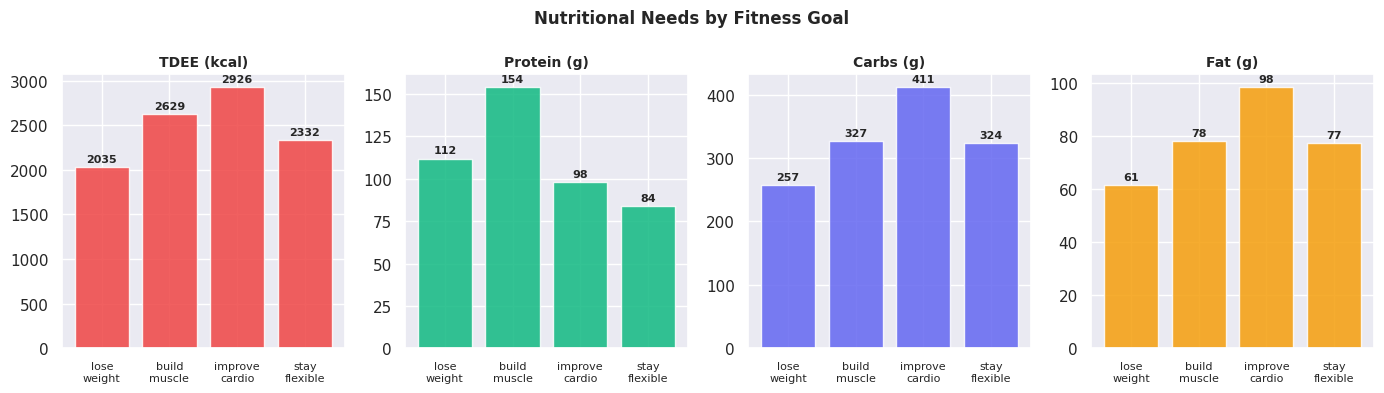

In [50]:
# Show how nutritional needs differ by goal — this is the signal our model uses
goals = ['lose weight', 'build muscle', 'improve cardio', 'stay flexible']
example_profiles = []

for goal in goals:
    needs = calculate_nutritional_needs(30, 70, 1.75, 'Male', goal)
    needs['goal'] = goal
    example_profiles.append(needs)

profiles_df = pd.DataFrame(example_profiles).set_index('goal')
print("Nutritional needs by goal (30y Male, 70kg, 1.75m):")
print(profiles_df)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Nutritional Needs by Fitness Goal', fontsize=12, fontweight='bold')

colors = ['#EF4444', '#10B981', '#6366F1', '#F59E0B']
metrics = ['tdee', 'protein_g', 'carb_g', 'fat_g']
labels  = ['TDEE (kcal)', 'Protein (g)', 'Carbs (g)', 'Fat (g)']

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    bars = ax.bar(range(len(goals)), profiles_df[metric],
                  color=color, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xticks(range(len(goals)))
    ax.set_xticklabels([g.replace(' ', '\n') for g in goals], fontsize=8)
    for bar, val in zip(bars, profiles_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + profiles_df[metric].max()*0.02,
                str(int(val)), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Full Recommendation Function

In [51]:
# Diet type stats for output
diet_stats    = df.groupby('diet_type')[['Calories', 'Proteins', 'Carbs', 'Fats']].mean().round(1)
cooking_stats = df.groupby(['diet_type', 'cooking_method']).size().reset_index(name='count')

# Workout stats
workout_stats = df.groupby('Workout_Type')[
    ['Calories_Burned', 'Session_Duration (hours)', 'Workout_Frequency (days/week)']
].mean().round(2)

def full_recommendation(age, weight_kg, height_m, gender, goal):
    bmi = weight_kg / (height_m ** 2)

    # 1. Nutritional needs
    needs = calculate_nutritional_needs(age, weight_kg, height_m, gender, goal)

    # 2. Workout recommendation — use encoded gender + scaler
    gender_enc = le_gender.transform([gender])[0]
    user_w = pd.DataFrame([{
        'Age':            age,
        'Weight (kg)':    weight_kg,
        'Height (m)':     height_m,
        'BMI':            bmi,
        'Fat_Percentage': bmi * 0.9,
        'Gender_enc':     gender_enc
    }])
    user_w_scaled = scaler_workout.transform(user_w)
    workout_rec   = knn_workout.predict(user_w_scaled)[0]
    workout_proba = knn_workout.predict_proba(user_w_scaled)[0]

    # 3. Diet recommendation
    needs_scaled = scaler_diet.transform([[
        needs['tdee'], needs['protein_g'], needs['carb_g'], needs['fat_g']
    ]])
    diet_rec = knn_diet.predict(needs_scaled)[0]

    # 4. Best cooking method
    best_cooking = cooking_stats[cooking_stats['diet_type'] == diet_rec]\
        .sort_values('count', ascending=False).iloc[0]['cooking_method']

    print(f"{'='*50}")
    print(f"  PERSONALIZED RECOMMENDATION")
    print(f"{'='*50}")
    print(f"  Profile: {age}y {gender}, {weight_kg}kg, {height_m}m, BMI: {bmi:.1f}")
    print(f"  Goal: {goal.title()}")
    print()
    print(f"  🏋️  WORKOUT: {workout_rec}")
    print(f"  Confidence: {max(workout_proba)*100:.0f}%")
    ws = workout_stats.loc[workout_rec]
    print(f"  Avg calories burned: {ws['Calories_Burned']:.0f} kcal")
    print(f"  Avg session: {ws['Session_Duration (hours)']:.1f} hrs, {ws['Workout_Frequency (days/week)']:.1f}x/week")
    print()
    print(f"  🥗  DIET: {diet_rec}")
    print(f"  Best cooking method: {best_cooking}")
    print(f"  Daily targets:")
    print(f"    Calories : {needs['tdee']} kcal")
    print(f"    Protein  : {needs['protein_g']}g")
    print(f"    Carbs    : {needs['carb_g']}g")
    print(f"    Fat      : {needs['fat_g']}g")
    print()
    return workout_rec, diet_rec, needs

# Examples
full_recommendation(25, 70, 1.75, 'Male',   'build muscle')
full_recommendation(30, 65, 1.65, 'Female', 'lose weight')
full_recommendation(22, 80, 1.80, 'Male',   'improve cardio')

  PERSONALIZED RECOMMENDATION
  Profile: 25y Male, 70kg, 1.75m, BMI: 22.9
  Goal: Build Muscle

  🏋️  WORKOUT: HIIT
  Confidence: 30%
  Avg calories burned: 1485 kcal
  Avg session: 1.2 hrs, 3.1x/week

  🥗  DIET: Balanced
  Best cooking method: Baked
  Daily targets:
    Calories : 2673 kcal
    Protein  : 154.0g
    Carbs    : 334.2g
    Fat      : 80.0g

  PERSONALIZED RECOMMENDATION
  Profile: 30y Female, 65kg, 1.65m, BMI: 23.9
  Goal: Lose Weight

  🏋️  WORKOUT: Cardio
  Confidence: 40%
  Avg calories burned: 1212 kcal
  Avg session: 1.3 hrs, 3.3x/week

  🥗  DIET: Vegan
  Best cooking method: Baked
  Daily targets:
    Calories : 1717 kcal
    Protein  : 104.0g
    Carbs    : 211.3g
    Fat      : 50.6g

  PERSONALIZED RECOMMENDATION
  Profile: 22y Male, 80kg, 1.8m, BMI: 24.7
  Goal: Improve Cardio

  🏋️  WORKOUT: Strength
  Confidence: 40%
  Avg calories burned: 1321 kcal
  Avg session: 1.3 hrs, 3.3x/week

  🥗  DIET: Vegan
  Best cooking method: Baked
  Daily targets:
    Calories

('Strength',
 'Vegan',
 {'tdee': 3276, 'protein_g': 112.0, 'carb_g': 459.6, 'fat_g': 110.0})

## 6. Export Models

In [53]:
os.makedirs('models/monta', exist_ok=True)

joblib.dump(knn_workout,  'models/monta/knn_workout.pkl')
joblib.dump(knn_diet,     'models/monta/knn_diet.pkl')
joblib.dump(scaler_diet,  'models/monta/scaler_diet.pkl')
joblib.dump(le_gender,    'models/monta/le_gender.pkl')
joblib.dump(scaler_workout, 'models/monta/scaler_workout.pkl')

# Save diet and workout stats for display in Streamlit
diet_stats.to_csv('models/monta/diet_stats.csv')
workout_stats.to_csv('models/monta/workout_stats.csv')

# Save cooking method stats
cooking_stats.to_csv('models/monta/cooking_stats.csv', index=False)

print('✅ Saved:')
print('   models/monta/knn_workout.pkl')
print('   models/monta/knn_diet.pkl')
print('   models/monta/scaler_diet.pkl')
print('   models/monta/diet_stats.csv')
print('   models/monta/workout_stats.csv')
print('   models/monta/cooking_stats.csv')


✅ Saved:
   models/monta/knn_workout.pkl
   models/monta/knn_diet.pkl
   models/monta/scaler_diet.pkl
   models/monta/diet_stats.csv
   models/monta/workout_stats.csv
   models/monta/cooking_stats.csv
